## Goals
- Learn to implement the model $f_{w,b}$ for linear regression with one variable

## Notation

 **Regression**
  $\mathbf{x}$ Training Example feature values (in this lab - Size (1000 sqft) `x_train`
$\mathbf{y}$ Training Example  targets (in this lab Price (1000s of dollars)) `y_train`
  $x^{(i)}$, $y^{(i)}$ $i_{th}$Training Example `x_i`, `y_i`
 Number of training examples `m`
  $w$  parameter: weight     `w`
  $b$  parameter: bias       `b`
 $f_{w,b}(x^{(i)})$ The result of the model evaluation at $x^{(i)}$ parameterized by $w,b$: $f_{w,b}(x^{(i)}) = wx^{(i)}+b$ `f_wb`


## Tools
- NumPy, a popular library for scientific computing
- Matplotlib, a popular library for plotting data

In [6]:
import numpy as np
import matplotlib.pyplot as plt

Creating `x_train` and `y_train` variables. The data is stored in one-dimensional NumPy arrays.

In [7]:
# x_train is the input variable (size in 1000 square feet)
# y_train is the target (price in 1000s of dollars)
x_train = np.array([1.0, 2.0])
y_train = np.array([300.0, 500.0])
print(f"x_train = {x_train}")
print(f"y_train = {y_train}")

x_train = [1. 2.]
y_train = [300. 500.]


### Number of training examples `m`
We will use `m` to denote the number of training examples. Numpy arrays have a `.shape` parameter. `x_train.shape` returns a python tuple (samples, features) with an entry for each dimension. `x_train.shape[0]` is the length of the array and number of samples.

In [16]:
# m is the number of training examples
print(f"x_train.shape: {x_train.shape}")
m = x_train.shape[0]
print(f"Number of training samples is: {m}")

x_train.shape: (2,)
Number of training samples is: 2


One can also use the Python `len()` function as shown below.

In [17]:
# m is the number of training examples
m = len(x_train)
print(f"Number of training samples is: {m}")

Number of training samples is: 2


### Training example `x_i, y_i`

We will use (x$^{(i)}$, y$^{(i)}$) to denote the $i^{th}$ training example. Since Python is zero indexed, (x$^{(0)}$, y$^{(0)}$) is (1.0, 300.0) and (x$^{(1)}$, y$^{(1)}$) is (2.0, 500.0).

To access a value in a Numpy array, one indexes the array with the desired offset. For example the syntax to access location zero of `x_train` is `x_train[0]`.
Run the next code block below to get the $i^{th}$ training example.

In [18]:
i = 0 # See (x^1, y^1)

x_i = x_train[i]
y_i = y_train[i]
print(f"(x^({i}), y^({i})) = ({x_i}, {y_i})")
i = 1 # Change this to 1 to see (x^1, y^1)

x_i = x_train[i]
y_i = y_train[i]
print(f"(x^({i}), y^({i})) = ({x_i}, {y_i})")

(x^(0), y^(0)) = (1.0, 300.0)
(x^(1), y^(1)) = (2.0, 500.0)


We can plot these two points using the `scatter()` function in the `matplotlib` library
- The function arguments `marker` and `c` show the points as red crosses.

We can use other functions in the `matplotlib` library to set the title and labels to display

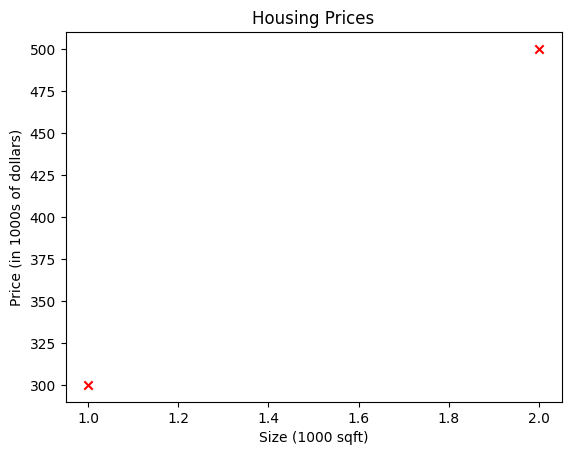

In [19]:
# Plot the data points
plt.scatter(x_train, y_train, marker='x', c='r')
# Set the title
plt.title("Housing Prices")
# Set the y-axis label
plt.ylabel('Price (in 1000s of dollars)')
# Set the x-axis label
plt.xlabel('Size (1000 sqft)')
plt.show()

The model function for linear regression (which is a function that maps from `x` to `y`)

$$ f_{w,b}(x^{(i)}) = wx^{(i)} + b $$

The formula above is how we can represent straight lines - different values of $w$ and $b$ give you different straight lines on the plot.

Try to get a better intuition start with $w = 100$ and $b = 100$.

In [20]:
w = 200
b = 100
print(f"w: {w}")
print(f"b: {b}")

w: 200
b: 100


Now, let's compute the value of $f_{w,b}(x^{(i)})$ for two data points. We can write this out for each data point as -

for $x^{(0)}$, `f_wb = w * x[0] + b`

for $x^{(1)}$, `f_wb = w * x[1] + b`

For a large number of data points, we can calculate the function output in a `for` loop as shown in the `compute_model_output` function.
> **Note**: The argument description `(ndarray (m,))` describes a Numpy n-dimensional array of shape (m,). `(scalar)` describes an argument without dimensions, just a magnitude.
> **Note**: `np.zero(n)` will return a one-dimensional numpy array with $n$ entries


In [21]:
def compute_model_output(x, w, b):
    """
    Computes the prediction of a linear model
    Args:
      x (ndarray (m,)): Data, m examples
      w,b (scalar)    : model parameters
    Returns
      f_wb (ndarray (m,)): model prediction
    """
    m = x.shape[0]
    f_wb = np.zeros(m)
    for i in range(m):
        f_wb[i] = w * x[i] + b

    return f_wb

Now let's call the `compute_model_output` function and plot the output..

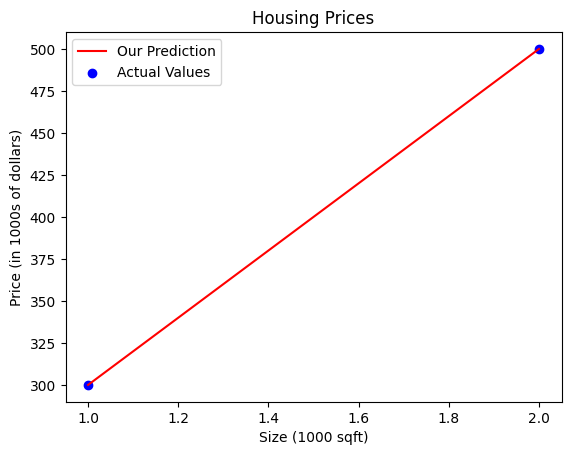

In [22]:
tmp_f_wb = compute_model_output(x_train, w, b,)

# Plot our model prediction
plt.plot(x_train, tmp_f_wb, c='r',label='Our Prediction')

# Plot the data points
plt.scatter(x_train, y_train, marker='o', c='b',label='Actual Values')

# Set the title
plt.title("Housing Prices")
# Set the y-axis label
plt.ylabel('Price (in 1000s of dollars)')
# Set the x-axis label
plt.xlabel('Size (1000 sqft)')
plt.legend()
plt.show()

### Prediction
Now that we have a model, we can use it to make our original prediction. Let's predict the price of a house with 1200 sqft. Since the units of $x$ are in 1000's of sqft, $x$ is 1.2.


In [15]:
w = 200
b = 100
x_i = 1.5
cost_1200sqft = w * x_i + b

print(f"${cost_1200sqft:.0f} thousand dollars")

$400 thousand dollars
